# Phylogenetic Tree

This notebook serves as an example for the visualisation of phylogenetic tree from CPM embedding. For more details, please refer to Figure 4 and Section 4.9 in our [paper](https://doi.org/10.1101/2025.08.22.671789).

We analyze data from [Pijuan-Sala et al. (2019)](#references), encompassing 116,312 cells from mouse embryos at nine developmental stages between embryonic days 6.5 and 8.5. This dataset captures the transcriptional dynamics during the critical phases of gastrulation and early organ formation. The dataset was normalized to 10000 counts per cell, Log1p transformed and filtered to contain 2000 highly variable genes. The trained model and the config files for CPM can be found [here](./results/mouse_gastrulation). We directly load the embedding for this example. 

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from helpers.poincare_maps import *
from model.poincare_loss import poincare_root
from helpers.visualize import plotPoincareDisc, plot_poincare_disc
import pandas as pd
from sklearn.model_selection import train_test_split

data_file = "./results/mouse_gastrulation/mouse_2000vargenes.csv"
embed_file = "./results/mouse_gastrulation/mouse_2000vargenesT_2048_1_1_4096_0.15_1000_emb.csv"
root = "Epiblast"

embedding = pd.read_csv(embed_file, header=None)
dataset = pd.read_csv(data_file)
target_cells = dataset.iloc[:, -1]

# we subsample the data in order to save space in this demonstration
_, idx = train_test_split(np.arange(0,len(dataset)), train_size=0.9, stratify=target_cells.values)
data = dataset.iloc[idx, :-2]
target_time = dataset.iloc[idx, -2]
target_cells = dataset.iloc[idx, -1]
embedding = embedding.iloc[idx, :].values

A simple phylogenetic tree is visualized by plotting Poincaré distances between the cells against the embryonic stage. The distances reflect developmental progression across lineages. The phylogenetic tree for the mouse gastrulation dataset reveals the presence of mature visceral endoderm cells as early as E6.5. This could be explained by the fact that the authors sampled extra-embryonic structures alongside the gastrulating embryo to investigate the convergence of primitive streak-derived definitive endoderm with visceral endoderm-derived cells at the molecular level. Visualizations of the phylogenetic tree with visceral endoderm in the endodermal lineage: 

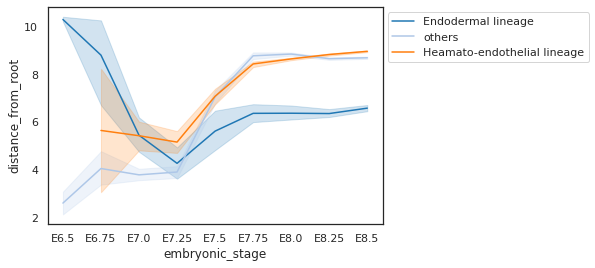

In [18]:
%matplotlib inline

# Apply root translation and compute distances with respect to root
root_hat = poincare_root(root, target_cells.astype(str).to_numpy(), data.to_numpy())
poincare_coord_new = poincare_translation(-embedding[root_hat, :], embedding)

model = PoincareMaps(poincare_coord_new)
model.get_distances()

# Divide the cells according to their lineage
endoderm_lin = ["Anterior Primitive Streak", "Def. endoderm", "Gut", "Visceral endoderm"]
hem_lin = ["Blood progenitors 1", "Blood progenitors 2", "Erythroid1", "Erythroid2", "Erythroid3",
           "Haematoendothelial progenitors", "Mixed mesoderm"]

df_to_plot = pd.DataFrame()
df_to_plot["distance_from_root"] = model.distances[model.iroot]
df_to_plot["embryonic_stage"] = target_time.values
df_to_plot["target_cells"] = target_cells.values

df_to_plot.loc[~(df_to_plot["target_cells"].isin(endoderm_lin+hem_lin)), "target_cells"] = "others"
df_to_plot.loc[df_to_plot["target_cells"].isin(endoderm_lin), "target_cells"] = "Endodermal lineage"
df_to_plot.loc[df_to_plot["target_cells"].isin(hem_lin), "target_cells"] = "Heamato-endothelial lineage"

# re-order the stages
custom_order = ["E6.5", "E6.75", "E7.0", "E7.25", "E7.5", "E7.75", "E8.0", "E8.25", "E8.5", "mixed_gastrulation"]
df_to_plot["embryonic_stage"] = pd.Categorical(df_to_plot["embryonic_stage"], categories=custom_order, ordered=True)

df_sorted = df_to_plot.sort_values(by="embryonic_stage")
df_sorted = df_sorted[df_sorted["embryonic_stage"]!="mixed_gastrulation"]

# plot the phylogenetic tree
fig, ax= plt.subplots()
sns.lineplot(data=df_sorted, x="embryonic_stage", y="distance_from_root", hue="target_cells", 
             sort=False, palette=sns.color_palette("tab20"), ax=ax)

sns.set_style("white")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None)


Visualizations of the phylogenetic tree without visceral endoderm in the endodermal lineage: 

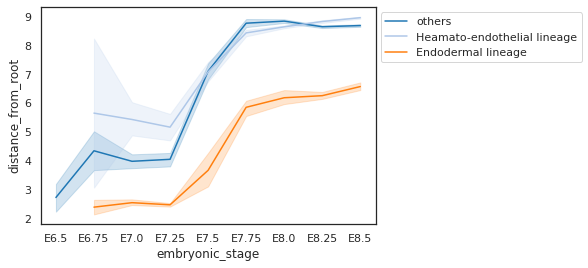

In [23]:
# remove visceral endoderm from endodermal lineage
endoderm_lin = ["Anterior Primitive Streak", "Def. endoderm", "Gut"]
hem_lin = ["Blood progenitors 1", "Blood progenitors 2", "Erythroid1", "Erythroid2", "Erythroid3",
           "Haematoendothelial progenitors", "Mixed mesoderm"]

df_to_plot = pd.DataFrame()
df_to_plot["distance_from_root"] = model.distances[model.iroot]
df_to_plot["embryonic_stage"] = target_time.values
df_to_plot["target_cells"] = target_cells.values

df_to_plot.loc[~(df_to_plot["target_cells"].isin(endoderm_lin+hem_lin)), "target_cells"] = "others"
df_to_plot.loc[df_to_plot["target_cells"].isin(endoderm_lin), "target_cells"] = "Endodermal lineage"
df_to_plot.loc[df_to_plot["target_cells"].isin(hem_lin), "target_cells"] = "Heamato-endothelial lineage"

# re-order the stages
custom_order = ["E6.5", "E6.75", "E7.0", "E7.25", "E7.5", "E7.75", "E8.0", "E8.25", "E8.5", "mixed_gastrulation"]
df_to_plot["embryonic_stage"] = pd.Categorical(df_to_plot["embryonic_stage"], categories=custom_order, ordered=True)

df_sorted = df_to_plot.sort_values(by="embryonic_stage")
df_sorted = df_sorted[df_sorted["embryonic_stage"]!="mixed_gastrulation"]

# plot the phylogenetic tree
fig, ax= plt.subplots()
sns.lineplot(data=df_sorted, x="embryonic_stage", y="distance_from_root", hue="target_cells", 
             sort=False, palette=sns.color_palette("tab20"), ax=ax)

sns.set_style("white")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None)

<a id="references"></a>

## References

1. Blanca Pijuan-Sala, Jonathan A Griffiths, Carolina Guibentif, Tom W Hiscock, Wajid Jawaid,
Fernando J Calero-Nieto, Carla Mulas, Ximena Ibarra-Soria, Richard C V Tyser, Debbie
Lee Lian Ho, Wolf Reik, Shankar Srinivas, Benjamin D Simons, Jennifer Nichols, John C
Marioni, and Berthold G¨ottgens. A single-cell molecular map of mouse gastrulation and early
organogenesis. Nature, 566(7745):490–495, 2019.